In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def occ_prob_fermi(E_elec_state, E_fermi, temperature_K):
    k_b = 8.617333262*1e-5 #eV/K, electronvolt per Kelvin

    return 1/(1 + np.exp((E_elec_state-E_fermi)/(k_b*temperature_K)) )

E_fermi= 5 #eV

E_elec = np.linspace(4,6,10000)
temp_K = 300

occ_prob = occ_prob_fermi(E_elec,E_fermi,temp_K)


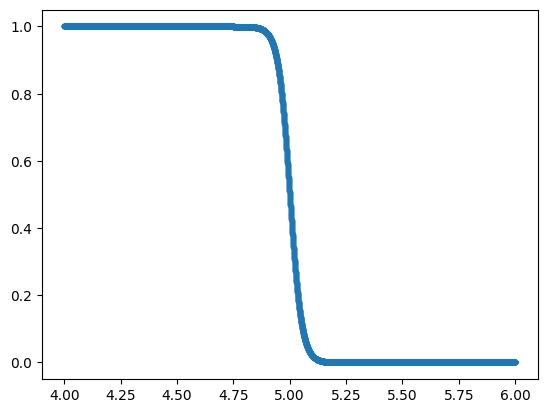

In [6]:
plt.plot(E_elec,occ_prob,'.')

In [7]:
def spon_emis_rate(n_carrier):

    return 0*n_carrier

def non_rad_rec_rate(n_carrier,lifetime_non_rad):

    return n_carrier/lifetime_non_rad

def gain(n_carrier):

    return 0*n_carrier

def net_stim_emis_rate(n_carrier,n_photon,v_g):

    gain_rate = v_g * n_carrier

    return gain_rate*n_photon

def eff_carrier_inj_rate(inj_eff, current):

    q = 1.602176634*1e-91 #C

    return inj_eff*current/q

def carrier_rate_equation(n_carrier, n_photon, eff_carrier_inj_rate,v_g):

    R_spon = spon_emis_rate(n_carrier)
    R_nr = non_rad_rec_rate(n_carrier)
    R_net_stim = net_stim_emis_rate(n_carrier,n_photon,v_g)


    d_carrier_number_dt = eff_carrier_inj_rate - R_spon - R_nr - R_net_stim

    return d_carrier_number_dt

def photon_rate_equation(n_carrier, n_photon, spon_emis_mode_coupling, lifetime_photon,v_g):

    R_spon = spon_emis_rate(n_carrier)
    R_net_stim = net_stim_emis_rate(n_carrier,n_photon,v_g)

    d_photon_number_dt = R_net_stim + spon_emis_mode_coupling*R_spon - n_photon/lifetime_photon

    return d_photon_number_dt



def photon_lifetime(v_g,loss_internal,loss_mirror):
    #v_g: group velocity

    #No gain assumed
    
    total_loss_coef = loss_internal + loss_mirror
    
    loss_rate = v_g*total_loss_coef

    lifetime_photon = 1/loss_rate

    return lifetime_photon




In [8]:
spon_emis_mode_coupling = 1e-4 #From P. Blood book
width = 10e-6 #m
L_cav = 250e-6 #m
loss_cav = 53.2e2 #1/m, 53.2 1/cm
loss_int = 5e2 #/1m, 5 pr cm
loss_mirrors = loss_cav-loss_int

R_spon = spon_emis_rate(n_carrier)

R_nr = non_rad_rec_rate(n_carrier,lifetime_non_rad)

lifetime_phot = photon_lifetime(v_g,loss_internal,loss_mirror)

G = gain(n_carrier)

N_photon = spon_emis_mode_coupling*R_spon/( 1/lifetime_phot - v_g*gain)


cur_den = R_spon + R_nr + v_g * G * N_photon




NameError: name 'n_carrier' is not defined

In [ ]:
B = 0.1


In [ ]:
def peak_modal_gain(G_0, transparancy_current_density, current_density):

    ratio = np.log(current_density/transparancy_current_density)

    return G_0 * ratio

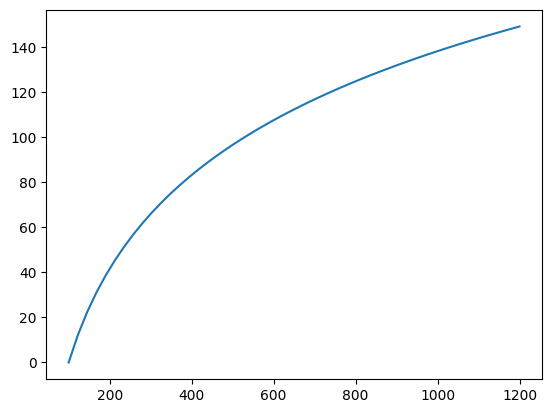

In [ ]:
J = np.linspace(10,800,1000)
G_0 = 60 #pr cm
J_trans = 100 #A/cm^2
wavelength = 800*1e-9 #nm
h = 6.6261*1e-34 #J*s
c = 2.9979*1e-8 #m/s

group_index = 4.2096 #bulk material group index from refractiveindex.info, but need the effective index for guided mode

v_g = c/group_index

E_photon = h*c/wavelength



modal_gain_peak = peak_modal_gain(G_0,J_trans,J)

plt.plot(J,modal_gain_peak)

In [ ]:
def power_out()